In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

load

In [4]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()
x_train.shape

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1903s 11us/step


(50000, 32, 32, 3)

In [5]:
x_test.shape

(10000, 32, 32, 3)

In [11]:
y_train.shape

(50000, 1)

In [12]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [13]:
y_train = y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [6]:
x_train[0]

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]

plot the image 

Frog

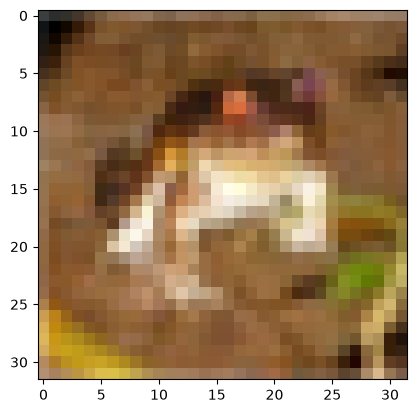

In [8]:
plt.imshow(x_train[0])

Truck

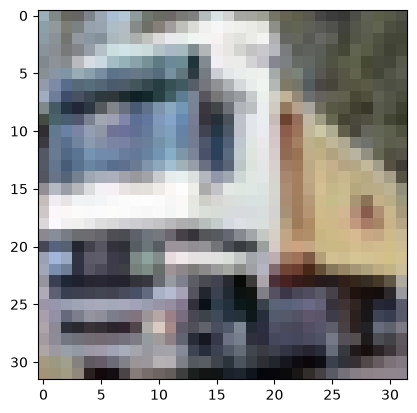

In [9]:
plt.imshow(x_train[1])

In [10]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [22]:
def plot_sample(x,y,index):
    plt.figure(figsize=(15,2))
    plt.imshow(x[index])
    plt.xlabel(classes[y[index]])

label the pic 


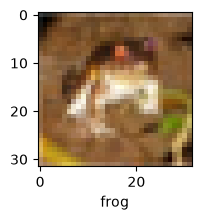

In [23]:
plot_sample(x_train, y_train, 0)

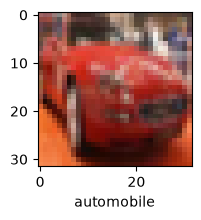

In [24]:
plot_sample(x_train, y_train, 5)

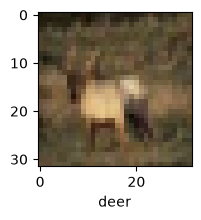

In [25]:
plot_sample(x_train, y_train, 3)

Normalizattion

In [26]:
x_train = x_train/225

In [27]:
x_test = x_test/225

In [29]:
ann = models.Sequential([
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(3000, activation='relu'),
    layers.Dense(1000, activation='relu'),
    layers.Dense(10, activation='sigmoid')
])

ann.compile(optimizer='SGD',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

ann.fit(x_train, y_train, epochs=5)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.3573 - loss: 1.8020
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.4321 - loss: 1.6109
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.4608 - loss: 1.5305
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.4837 - loss: 1.4709
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.4991 - loss: 1.4218


In [31]:
cnn = models.Sequential([

    #nn
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),


    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax'),
   
])

cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

cnn.fit(x_train, y_train, epochs=5)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4791 - loss: 1.4491
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6179 - loss: 1.0899
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6607 - loss: 0.9735
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6895 - loss: 0.8939
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7111 - loss: 0.8299


In [32]:
cnn.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6711 - loss: 0.9530


[0.9530081748962402, 0.6711000204086304]

In [33]:
y_test = y_test.reshape(-1,)
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0977777777777777].


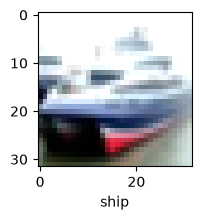

In [ ]:
plot_sample(x_test, y_test, 1)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1333333333333333].


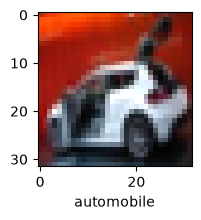

In [35]:
plot_sample(x_test, y_test, 6)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.057777777777777775..1.1333333333333333].


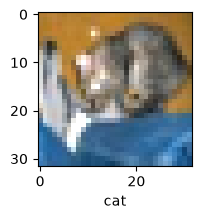

In [36]:
plot_sample(x_test, y_test, 0)

In [37]:
y_pred = cnn.predict(x_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([[6.0762423e-03, 2.6289350e-04, 5.8466396e-03, 4.4037738e-01,
        5.6908848e-03, 3.4713876e-01, 9.6803412e-02, 2.6348158e-04,
        9.0374202e-02, 7.1659605e-03],
       [3.9013632e-02, 1.0398975e-01, 1.9765917e-04, 6.5393026e-05,
        6.4079541e-05, 7.7316172e-06, 1.6859114e-05, 1.6260628e-06,
        8.3838606e-01, 1.8257177e-02],
       [7.6834865e-02, 1.4033033e-01, 6.4928974e-03, 4.3902945e-02,
        4.7266982e-03, 5.6589809e-03, 9.2532346e-03, 3.2987604e-03,
        6.8590474e-01, 2.3596488e-02],
       [6.7517000e-01, 2.1490227e-02, 7.5700484e-02, 1.4599302e-02,
        2.3120955e-02, 5.3069525e-04, 1.7268706e-02, 5.7747397e-03,
        1.6014934e-01, 6.1954600e-03],
       [3.1037562e-06, 2.8050560e-04, 6.4129066e-03, 2.2745444e-02,
        6.6345900e-02, 9.5584569e-03, 8.9437735e-01, 4.9335806e-05,
        2.1515028e-04, 1.1937762e-05]], dtype=float32)

In [39]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[ : 5]

[np.int64(3), np.int64(8), np.int64(8), np.int64(0), np.int64(6)]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.057777777777777775..1.1333333333333333].


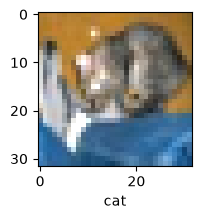

In [40]:
plot_sample(x_test, y_test, 0)

In [41]:
 classes[y_classes[0]]

'cat'

q

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.14666666666666667..1.04].


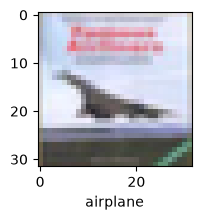

In [42]:
plot_sample(x_test, y_test, 3)

predection


In [43]:
 classes[y_classes[3]]

'airplane'

q

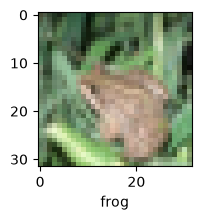

In [50]:
plot_sample(x_test, y_test, 4)

prediction


In [44]:
 classes[y_classes[4]]

'frog'

q

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1333333333333333].


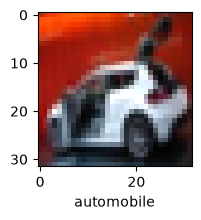

In [51]:
plot_sample(x_test, y_test, 6)

prediction

In [46]:
 classes[y_classes[6]]

'automobile'

q

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.08888888888888889..1.1155555555555556].


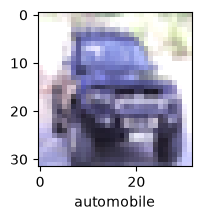

In [52]:
plot_sample(x_test, y_test, 9)

Prediction 

In [48]:
 classes[y_classes[9]]

'automobile'